# Task 1

Цель: собрать признаки, которые объясняют исход матча, и сравнить с бейзлайном букмекеров (implied probability).


In [1]:
import pandas as pd
import numpy as np

ods = pd.read_parquet('ods.parquet')
tml = pd.read_parquet('tml.parquet')
players = pd.read_parquet('players.parquet')

ods['Date'] = pd.to_datetime(ods['Date'])
tml['tourney_date'] = pd.to_datetime(tml['tourney_date'].astype(str), format='%Y%m%d', errors='coerce')

(ods.shape, tml.shape, players.shape)

((22851, 42), (24939, 50), (7643, 12))

In [2]:
import re

def key_from_odds(name: str) -> str:
    if pd.isna(name):
        return ''
    s = str(name).strip().lower()
    s = s.replace("'", "").replace('-', ' ')
    s = re.sub(r"\s+", " ", s)
    parts = s.split(' ')
    if not parts:
        return ''
    init = re.sub(r"[^a-z]", "", parts[-1].replace('.', ''))[:1]
    surname = re.sub(r"[^a-z\s]", "", ' '.join(parts[:-1])).strip()
    return f"{surname} {init}".strip()

def key_from_tml(full_name: str) -> str:
    if pd.isna(full_name):
        return ''
    s = str(full_name).strip().lower()
    s = s.replace("'", "").replace('-', ' ')
    s = re.sub(r"\s+", " ", s)
    parts = s.split(' ')
    if not parts:
        return ''
    if len(parts) == 1:
        return re.sub(r"[^a-z]", "", parts[0])
    init = re.sub(r"[^a-z]", "", parts[0])[:1]
    surname = re.sub(r"[^a-z\s]", "", ' '.join(parts[1:])).strip()
    return f"{surname} {init}".strip()

ods['week'] = (ods['Date'] - pd.to_timedelta(ods['Date'].dt.weekday, unit='D')).dt.normalize()
tml['week'] = tml['tourney_date'].dt.normalize()

ods['wkey'] = ods['Winner'].map(key_from_odds)
ods['lkey'] = ods['Loser'].map(key_from_odds)
tml['wkey'] = tml['winner_name'].map(key_from_tml)
tml['lkey'] = tml['loser_name'].map(key_from_tml)

ods['p1'] = ods[['wkey', 'lkey']].min(axis=1)
ods['p2'] = ods[['wkey', 'lkey']].max(axis=1)
tml['p1'] = tml[['wkey', 'lkey']].min(axis=1)
tml['p2'] = tml[['wkey', 'lkey']].max(axis=1)

ods[['week', 'Winner', 'Loser', 'p1', 'p2']].head(3)

,week,Winner,Loser,p1,p2
0,2017-12-25,Dolgopolov O.,Schwartzman D.,dolgopolov o,schwartzman d
1,2017-12-25,De Minaur A.,Johnson S.,de minaur a,johnson s
2,2018-01-01,Harrison R.,Mayer L.,harrison r,mayer l


In [3]:
# Join on (week, p1, p2). This yields ~70% coverage and is robust to tournament name mismatches.
joined = tml.merge(
    ods,
    how='inner',
    on=['week', 'p1', 'p2'],
    suffixes=('_tml', '_ods')
)

print('joined shape:', joined.shape)
print('match rate tml:', round(joined.shape[0] / tml.shape[0], 3))
print('match rate ods:', round(joined.shape[0] / ods.shape[0], 3))

# surface sanity check
print('surface agree:', round((joined['surface'].str.lower() == joined['Surface'].str.lower()).mean(), 4))

joined[['week','winner_name','loser_name','Winner','Loser','surface','Surface','B365W','B365L','PSW','PSL']].head(5)

joined shape: (17633, 99)
match rate tml: 0.707
match rate ods: 0.772
surface agree: 0.996


,week,winner_name,loser_name,Winner,Loser,surface,Surface,B365W,B365L,PSW,PSL
0,2017-01-02,Viktor Troicki,Yoshihito Nishioka,Troicki V.,Nishioka Y.,Hard,Hard,1.50,2.50,1.54,2.62
1,2017-01-02,Kyle Edmund,Ernesto Escobedo,Edmund K.,Escobedo E.,Hard,Hard,1.36,3.00,1.42,3.09
2,2017-01-02,Lucas Pouille,Gilles Simon,Pouille L.,Simon G.,Hard,Hard,1.80,1.90,1.93,1.95
3,2017-01-02,Jared Donaldson,Gilles Muller,Donaldson J.,Muller G.,Hard,Hard,2.62,1.44,2.74,1.51
4,2017-01-02,David Ferrer,Bernard Tomic,Ferrer D.,Tomic B.,Hard,Hard,1.90,1.80,2.10,1.81


In [4]:
# Build training frame in symmetric form: target is whether p1 won
joined = joined.copy()

joined['winner_key'] = joined['winner_name'].map(key_from_tml)
joined['loser_key'] = joined['loser_name'].map(key_from_tml)

joined['y_p1_win'] = (joined['winner_key'] == joined['p1']).astype(int)

# ranks for p1/p2 from tml
joined['rank_p1'] = np.where(joined['winner_key'] == joined['p1'], joined['winner_rank'], joined['loser_rank'])
joined['rank_p2'] = np.where(joined['winner_key'] == joined['p2'], joined['winner_rank'], joined['loser_rank'])
joined['rank_diff_p1_minus_p2'] = joined['rank_p1'] - joined['rank_p2']

# odds for p1/p2 from B365 and Pinnacle (PS)
joined['b365_odds_p1'] = np.where(joined['winner_key'] == joined['p1'], joined['B365W'], joined['B365L'])
joined['b365_odds_p2'] = np.where(joined['winner_key'] == joined['p2'], joined['B365W'], joined['B365L'])

joined['ps_odds_p1'] = np.where(joined['winner_key'] == joined['p1'], joined['PSW'], joined['PSL'])
joined['ps_odds_p2'] = np.where(joined['winner_key'] == joined['p2'], joined['PSW'], joined['PSL'])

# implied probabilities (normalize overround per match)
for prefix in ['b365', 'ps']:
    op1 = joined[f'{prefix}_odds_p1']
    op2 = joined[f'{prefix}_odds_p2']
    p1 = 1.0 / op1
    p2 = 1.0 / op2
    s = p1 + p2
    joined[f'{prefix}_imp_p1'] = p1 / s
    joined[f'{prefix}_imp_p2'] = p2 / s

joined[['week','p1','p2','y_p1_win','rank_diff_p1_minus_p2','b365_imp_p1','ps_imp_p1','surface']].head(5)

,week,p1,p2,y_p1_win,rank_diff_p1_minus_p2,b365_imp_p1,ps_imp_p1,surface
0,2017-01-02,nishioka y,troicki v,0,71.0,0.375000,0.370192,Hard
1,2017-01-02,edmund k,escobedo e,1,-96.0,0.688073,0.685144,Hard
2,2017-01-02,pouille l,simon g,1,-10.0,0.513514,0.502577,Hard
3,2017-01-02,donaldson j,muller g,1,71.0,0.354680,0.355294,Hard
4,2017-01-02,ferrer d,tomic b,1,-5.0,0.486486,0.462916,Hard


In [5]:
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score

baseline = joined.dropna(subset=['ps_imp_p1', 'y_p1_win']).copy()
y = baseline['y_p1_win'].to_numpy()
p = baseline['ps_imp_p1'].clip(1e-6, 1 - 1e-6).to_numpy()

print('baseline n:', len(baseline))
print('baseline logloss:', round(log_loss(y, p), 4))
print('baseline roc_auc:', round(roc_auc_score(y, p), 4))
print('baseline acc@0.5:', round(accuracy_score(y, p >= 0.5), 4))

baseline n: 17477
baseline logloss: 0.5903
baseline roc_auc: 0.7477
baseline acc@0.5: 0.6781


In [6]:
# Deduplicate after join: keep one odds row per TML match
joined['tml_match_id'] = joined['tourney_id'].astype(str) + '_' + joined['match_num'].fillna(-1).astype(int).astype(str) + '_' + joined['winner_id'].astype(str) + '_' + joined['loser_id'].astype(str)

before = joined.shape[0]
joined = joined.sort_values(['week', 'tourney_id', 'match_num']).drop_duplicates('tml_match_id', keep='first').reset_index(drop=True)
print('dedup:', before, '->', joined.shape[0])

dedup: 17633 -> 17624


In [7]:
# Add ranking points features (rating exists and is informative)
joined['rank_points_p1'] = np.where(joined['winner_key'] == joined['p1'], joined['winner_rank_points'], joined['loser_rank_points'])
joined['rank_points_p2'] = np.where(joined['winner_key'] == joined['p2'], joined['winner_rank_points'], joined['loser_rank_points'])
joined['rank_points_diff_p1_minus_p2'] = joined['rank_points_p1'] - joined['rank_points_p2']

joined[['rank_p1','rank_p2','rank_diff_p1_minus_p2','rank_points_p1','rank_points_p2','rank_points_diff_p1_minus_p2']].head(3)

,rank_p1,rank_p2,rank_diff_p1_minus_p2,rank_points_p1,rank_points_p2,rank_points_diff_p1_minus_p2
0,100.0,29.0,71.0,604.0,1385.0,-781.0
1,45.0,141.0,-96.0,1001.0,443.0,558.0
2,15.0,25.0,-10.0,2156.0,1585.0,571.0


In [8]:
def add_h2h_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(['week']).copy()

    # key independent of p1/p2 order
    df['pair_key'] = df['p1'] + '|' + df['p2']

    # winner relative to p1
    df['p1_win'] = df['y_p1_win'].astype(int)

    # cumulative h2h before current match
    df['h2h_p1_wins_before'] = df.groupby('pair_key')['p1_win'].cumsum().shift(1).fillna(0).astype(int)
    df['h2h_matches_before'] = df.groupby('pair_key').cumcount()
    df['h2h_p1_winrate_before'] = np.where(
        df['h2h_matches_before'] > 0,
        df['h2h_p1_wins_before'] / df['h2h_matches_before'],
        np.nan,
    )

    # centered feature: (p1 wins - p2 wins)
    df['h2h_p1_minus_p2_before'] = df['h2h_p1_wins_before'] - (df['h2h_matches_before'] - df['h2h_p1_wins_before'])

    return df.drop(columns=['pair_key', 'p1_win'])

joined = add_h2h_features(joined)
joined[['week','p1','p2','h2h_matches_before','h2h_p1_wins_before','h2h_p1_minus_p2_before','h2h_p1_winrate_before']].head(8)

,week,p1,p2,h2h_matches_before,h2h_p1_wins_before,h2h_p1_minus_p2_before,h2h_p1_winrate_before
0,2017-01-02,nishioka y,troicki v,0,0,0,NaN
54,2017-01-02,kravchuk k,paire b,0,0,0,NaN
53,2017-01-02,bhambri y,ramanathan r,0,0,0,NaN
52,2017-01-02,bedene a,garcia lopez g,0,1,2,NaN
51,2017-01-02,myneni s,youzhny m,0,1,2,NaN
50,2017-01-02,olivo r,ruud c,0,0,0,NaN
49,2017-01-02,dutra silva r,lajovic d,0,1,2,NaN
47,2017-01-02,berdych t,murray a,0,1,2,NaN


In [9]:
def add_form_features(df: pd.DataFrame, n: int = 10) -> pd.DataFrame:
    df = df.sort_values(['week']).copy()
    df = df.reset_index(drop=True)

    df['match_row_id'] = np.arange(len(df), dtype=int)

    long = pd.concat([
        pd.DataFrame({
            'match_row_id': df['match_row_id'],
            'week': df['week'],
            'role': 'p1',
            'player': df['p1'],
            'is_win': df['y_p1_win'].astype(int),
        }),
        pd.DataFrame({
            'match_row_id': df['match_row_id'],
            'week': df['week'],
            'role': 'p2',
            'player': df['p2'],
            'is_win': (1 - df['y_p1_win'].astype(int)),
        }),
    ], ignore_index=True)

    long = long.sort_values(['player', 'week', 'match_row_id'])

    long['form_winrate'] = (
        long.groupby('player')['is_win']
        .transform(lambda s: s.shift(1).rolling(n, min_periods=1).mean())
    )

    wide = (
        long.pivot(index='match_row_id', columns='role', values='form_winrate')
        .rename(columns={'p1': f'form_p1_last{n}', 'p2': f'form_p2_last{n}'})
        .reset_index()
    )

    out = df.merge(wide, on='match_row_id', how='left')
    out[f'form_diff_p1_minus_p2_last{n}'] = out[f'form_p1_last{n}'] - out[f'form_p2_last{n}']

    return out.drop(columns=['match_row_id'])

joined = add_form_features(joined, n=10)
joined[['form_p1_last10','form_p2_last10','form_diff_p1_minus_p2_last10']].sample(5)

,form_p1_last10,form_p2_last10,form_diff_p1_minus_p2_last10
16013,0.125,0.0,0.125
5231,0.300,0.6,-0.300
6219,0.400,0.3,0.100
3648,0.400,0.6,-0.200
13209,0.600,0.4,0.200


In [10]:
# Prepare features + time-based split
cutoff = pd.Timestamp('2024-01-01')

df = joined.copy()

# Ensure engineered features do not contain NaN
for c in ['h2h_p1_winrate_before', 'form_p1_last10', 'form_p2_last10']:
    if c in df.columns:
        df[c] = df[c].fillna(0.5)

for c in ['h2h_p1_minus_p2_before', 'h2h_matches_before', 'h2h_p1_wins_before']:
    if c in df.columns:
        df[c] = df[c].fillna(0)

# Implied probs can be missing when odds missing
for c in ['ps_imp_p1', 'b365_imp_p1']:
    if c in df.columns:
        df[c] = df[c].fillna(0.5)

# form diff might still be NaN if one side missing
if 'form_diff_p1_minus_p2_last10' in df.columns:
    df['form_diff_p1_minus_p2_last10'] = df['form_diff_p1_minus_p2_last10'].fillna(0)

# choose feature set
feature_cols_num = [
    'rank_diff_p1_minus_p2',
    'rank_points_diff_p1_minus_p2',
    'ps_imp_p1',
    'b365_imp_p1',
    'h2h_p1_minus_p2_before',
    'form_diff_p1_minus_p2_last10',
]
feature_cols_cat = ['surface']

# keep only existing columns
feature_cols_num = [c for c in feature_cols_num if c in df.columns]
feature_cols_cat = [c for c in feature_cols_cat if c in df.columns]

model_df = df.dropna(subset=['y_p1_win', 'week']).copy()

train_df = model_df[model_df['week'] < cutoff].copy()
test_df = model_df[model_df['week'] >= cutoff].copy()

print('train:', train_df.shape, 'test:', test_df.shape)
print('cutoff:', cutoff.date())

X_train = train_df[feature_cols_num + feature_cols_cat]
y_train = train_df['y_p1_win'].astype(int)
X_test = test_df[feature_cols_num + feature_cols_cat]
y_test = test_df['y_p1_win'].astype(int)

(feature_cols_num, feature_cols_cat)

train: (14092, 124) test: (3532, 124)
cutoff: 2024-01-01


(['rank_diff_p1_minus_p2',
  'rank_points_diff_p1_minus_p2',
  'ps_imp_p1',
  'b365_imp_p1',
  'h2h_p1_minus_p2_before',
  'form_diff_p1_minus_p2_last10'],
 ['surface'])

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score

numeric_features = feature_cols_num
categorical_features = feature_cols_cat

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='drop'
)

models = {
    'baseline_ps_imp': None,
    'gnb': Pipeline(steps=[('preprocess', preprocess), ('model', GaussianNB())]),
    'logreg': Pipeline(steps=[('preprocess', preprocess), ('model', LogisticRegression(max_iter=2000))]),
}

def eval_probs(y_true, p_pred, name: str):
    y_true = np.asarray(y_true, dtype=float)
    p_pred = np.asarray(p_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(p_pred)
    y_true = y_true[mask].astype(int)
    p_pred = p_pred[mask].clip(1e-6, 1 - 1e-6)

    out = {
        'model': name,
        'n': int(len(y_true)),
        'logloss': float(log_loss(y_true, p_pred)),
        'roc_auc': float(roc_auc_score(y_true, p_pred)),
        'acc@0.5': float(accuracy_score(y_true, p_pred >= 0.5)),
    }
    return out

results = []

# Baseline evaluated on test only
if 'ps_imp_p1' in test_df.columns:
    results.append(eval_probs(y_test, test_df['ps_imp_p1'], 'baseline_ps_imp'))

for name, pipe in models.items():
    if pipe is None:
        continue
    pipe.fit(X_train, y_train)
    p = pipe.predict_proba(X_test)[:, 1]
    results.append(eval_probs(y_test, p, name))

res_df = pd.DataFrame(results).sort_values('logloss')
res_df

,model,n,logloss,roc_auc,acc@0.5
2,logreg,3532,0.599893,0.738875,0.678086
0,baseline_ps_imp,3532,0.601141,0.736808,0.672424
1,gnb,3532,0.794028,0.731495,0.665062


In [12]:
# Ablation study + coefficient inspection + calibration
from sklearn.base import clone
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

base_num = {
    'ps': ['ps_imp_p1'],
    'odds': ['ps_imp_p1', 'b365_imp_p1'],
    'rank': ['rank_diff_p1_minus_p2', 'rank_points_diff_p1_minus_p2'],
    'h2h': ['h2h_p1_minus_p2_before'],
    'form': ['form_diff_p1_minus_p2_last10'],
}

def cols_exist(cols):
    return [c for c in cols if c in X_train.columns]

ablations = {
    'A_baseline_ps_only': cols_exist(base_num['ps']),
    'B_odds': cols_exist(base_num['odds']),
    'C_odds+rank': cols_exist(base_num['odds'] + base_num['rank']),
    'D_odds+rank+surface': cols_exist(base_num['odds'] + base_num['rank']) + feature_cols_cat,
    'E_+h2h': cols_exist(base_num['odds'] + base_num['rank'] + base_num['h2h']) + feature_cols_cat,
    'F_+h2h+form': cols_exist(base_num['odds'] + base_num['rank'] + base_num['h2h'] + base_num['form']) + feature_cols_cat,
}

pipe_template = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=2000))
])

rows = []
pred_store = {}

for name, cols in ablations.items():
    # rebuild preprocess with the selected columns
    num_cols = [c for c in cols if c in feature_cols_num]
    cat_cols = [c for c in cols if c in feature_cols_cat]

    numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ])

    local_preprocess = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num_cols),
            ('cat', categorical_transformer, cat_cols),
        ],
        remainder='drop'
    )

    pipe = Pipeline(steps=[('preprocess', local_preprocess), ('model', LogisticRegression(max_iter=2000))])

    pipe.fit(train_df[cols], y_train)
    p = pipe.predict_proba(test_df[cols])[:, 1]
    pred_store[name] = (p, pipe, cols)

    m = eval_probs(y_test, p, name)
    rows.append(m)

ablation_df = pd.DataFrame(rows).sort_values('logloss')
ablation_df

,model,n,logloss,roc_auc,acc@0.5
1,B_odds,3532,0.599467,0.739640,0.676954
2,C_odds+rank,3532,0.599468,0.739656,0.676104
5,F_+h2h+form,3532,0.599859,0.738935,0.677803
4,E_+h2h,3532,0.600065,0.738832,0.675821
3,D_odds+rank+surface,3532,0.600114,0.738665,0.674972
0,A_baseline_ps_only,3532,0.601433,0.736808,0.672990


best ablation: B_odds
Top +coef (pushes p1 win):


,feature,coef
0,num__ps_imp_p1,3.373275
1,num__b365_imp_p1,1.407335


Top -coef (pushes p1 lose):


,feature,coef
1,num__b365_imp_p1,1.407335
0,num__ps_imp_p1,3.373275


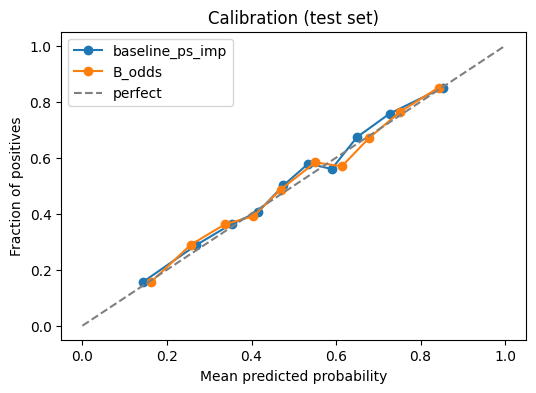

In [13]:
# Inspect best ablation: coefficients + calibration plot
best_name = ablation_df.sort_values('logloss').iloc[0]['model']
print('best ablation:', best_name)

p_best, best_pipe, best_cols = pred_store[best_name]

# Coefficients (including one-hot for surface)
pre = best_pipe.named_steps['preprocess']
clf = best_pipe.named_steps['model']

try:
    feature_names = pre.get_feature_names_out()
except Exception:
    feature_names = np.array([f'f{i}' for i in range(len(clf.coef_.ravel()))])

coef = clf.coef_.ravel()
coef_df = pd.DataFrame({'feature': feature_names, 'coef': coef})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

print('Top +coef (pushes p1 win):')
display(coef_df.sort_values('coef', ascending=False).head(15)[['feature','coef']])
print('Top -coef (pushes p1 lose):')
display(coef_df.sort_values('coef', ascending=True).head(15)[['feature','coef']])

# Calibration curves on test
fig, ax = plt.subplots(figsize=(6, 4))

# baseline: ps_imp_p1 (after fillna in split cell it is finite)
p_base = test_df['ps_imp_p1'].to_numpy(dtype=float)
mask = np.isfinite(y_test.to_numpy()) & np.isfinite(p_base)
frac_pos, mean_pred = calibration_curve(y_test.to_numpy()[mask], p_base[mask], n_bins=10, strategy='quantile')
ax.plot(mean_pred, frac_pos, marker='o', label='baseline_ps_imp')

mask2 = np.isfinite(y_test.to_numpy()) & np.isfinite(p_best)
frac_pos2, mean_pred2 = calibration_curve(y_test.to_numpy()[mask2], p_best[mask2], n_bins=10, strategy='quantile')
ax.plot(mean_pred2, frac_pos2, marker='o', label=best_name)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='perfect')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration (test set)')
ax.legend()
plt.show()

In [14]:
# Two-cutoff evaluation + no-odds baselines + odds-vs-rank correlation
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score


def eval_probs_masked(y_true, p_pred, name: str):
    y_true = np.asarray(y_true, dtype=float)
    p_pred = np.asarray(p_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(p_pred)
    y_true = y_true[mask].astype(int)
    p_pred = p_pred[mask].clip(1e-6, 1 - 1e-6)
    return {
        'model': name,
        'n': int(len(y_true)),
        'logloss': float(log_loss(y_true, p_pred)),
        'roc_auc': float(roc_auc_score(y_true, p_pred)),
        'acc@0.5': float(accuracy_score(y_true, p_pred >= 0.5)),
    }


def build_preprocess(num_cols, cat_cols):
    numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ])
    return ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num_cols),
            ('cat', categorical_transformer, cat_cols),
        ],
        remainder='drop'
    )


def run_suite(cutoff: str):
    cutoff = pd.Timestamp(cutoff)
    df0 = joined.copy()

    # fill engineered features
    for c in ['h2h_p1_winrate_before', 'form_p1_last10', 'form_p2_last10']:
        if c in df0.columns:
            df0[c] = df0[c].fillna(0.5)
    for c in ['h2h_p1_minus_p2_before', 'h2h_matches_before', 'h2h_p1_wins_before']:
        if c in df0.columns:
            df0[c] = df0[c].fillna(0)

    # keep odds as-is for correlation; for modeling impute later
    if 'form_diff_p1_minus_p2_last10' in df0.columns:
        df0['form_diff_p1_minus_p2_last10'] = df0['form_diff_p1_minus_p2_last10'].fillna(0)

    model_df = df0.dropna(subset=['y_p1_win', 'week']).copy()
    train_df = model_df[model_df['week'] < cutoff].copy()
    test_df = model_df[model_df['week'] >= cutoff].copy()

    y_train = train_df['y_p1_win'].astype(int)
    y_test = test_df['y_p1_win'].astype(int)

    # define feature sets
    sets = {
        'A_baseline_ps_only': ['ps_imp_p1'],
        'B_odds': ['ps_imp_p1', 'b365_imp_p1'],
        'C_odds+rank': ['ps_imp_p1', 'b365_imp_p1', 'rank_diff_p1_minus_p2', 'rank_points_diff_p1_minus_p2'],
        'D_odds+rank+surface': ['ps_imp_p1', 'b365_imp_p1', 'rank_diff_p1_minus_p2', 'rank_points_diff_p1_minus_p2', 'surface'],
        'E_+h2h': ['ps_imp_p1', 'b365_imp_p1', 'rank_diff_p1_minus_p2', 'rank_points_diff_p1_minus_p2', 'surface', 'h2h_p1_minus_p2_before'],
        'F_+h2h+form': ['ps_imp_p1', 'b365_imp_p1', 'rank_diff_p1_minus_p2', 'rank_points_diff_p1_minus_p2', 'surface', 'h2h_p1_minus_p2_before', 'form_diff_p1_minus_p2_last10'],

        # no-odds controls
        'G_rank_only': ['rank_diff_p1_minus_p2', 'rank_points_diff_p1_minus_p2'],
        'H_surface_only': ['surface'],
        'I_h2h+form_only': ['h2h_p1_minus_p2_before', 'form_diff_p1_minus_p2_last10'],
        'J_rank+surface+h2h+form': ['rank_diff_p1_minus_p2', 'rank_points_diff_p1_minus_p2', 'surface', 'h2h_p1_minus_p2_before', 'form_diff_p1_minus_p2_last10'],
    }

    rows = []
    for name, cols in sets.items():
        cols = [c for c in cols if c in train_df.columns]
        if not cols:
            continue

        # baseline: use ps only directly when present
        if name == 'A_baseline_ps_only' and 'ps_imp_p1' in test_df.columns:
            rows.append({**eval_probs_masked(y_test, test_df['ps_imp_p1'], name), 'cutoff': str(cutoff.date())})
            continue

        num_cols = [c for c in cols if c != 'surface']
        cat_cols = [c for c in cols if c == 'surface']

        pre = build_preprocess(num_cols, cat_cols)
        pipe = Pipeline(steps=[('preprocess', pre), ('model', LogisticRegression(max_iter=2000))])

        X_train = train_df[cols].copy()
        X_test = test_df[cols].copy()

        # fill missing odds for modeling
        for oc in ['ps_imp_p1', 'b365_imp_p1']:
            if oc in X_train.columns:
                X_train[oc] = X_train[oc].fillna(0.5)
                X_test[oc] = X_test[oc].fillna(0.5)

        pipe.fit(X_train, y_train)
        p = pipe.predict_proba(X_test)[:, 1]
        rows.append({**eval_probs_masked(y_test, p, name), 'cutoff': str(cutoff.date())})

    # correlations on test (only where both are finite)
    corr_rows = []
    if 'ps_imp_p1' in test_df.columns and 'rank_diff_p1_minus_p2' in test_df.columns:
        tmp = test_df[['ps_imp_p1', 'rank_diff_p1_minus_p2', 'rank_points_diff_p1_minus_p2']].copy()
        tmp = tmp[np.isfinite(tmp['ps_imp_p1']) & np.isfinite(tmp['rank_diff_p1_minus_p2'])]
        if len(tmp) > 10:
            corr_rows.append({
                'cutoff': str(cutoff.date()),
                'corr_ps_imp_vs_rank_diff': float(tmp['ps_imp_p1'].corr(tmp['rank_diff_p1_minus_p2'])),
                'corr_ps_imp_vs_rank_points_diff': float(tmp['ps_imp_p1'].corr(tmp['rank_points_diff_p1_minus_p2'])),
                'n_corr': int(len(tmp)),
            })

    return pd.DataFrame(rows), pd.DataFrame(corr_rows)


res_2024, corr_2024 = run_suite('2024-01-01')
res_2025, corr_2025 = run_suite('2025-01-01')

all_res = pd.concat([res_2024, res_2025], ignore_index=True)
all_res = all_res.sort_values(['cutoff', 'logloss'])

corr_all = pd.concat([corr_2024, corr_2025], ignore_index=True)

print('=== Metrics (sorted by cutoff, logloss) ===')
display(all_res)
print('=== Correlations (ps_imp_p1 vs rank diffs on test) ===')
display(corr_all)

=== Metrics (sorted by cutoff, logloss) ===


,model,n,logloss,roc_auc,acc@0.5,cutoff
0,A_baseline_ps_only,3445,0.598817,0.740047,0.675762,2024-01-01
1,B_odds,3532,0.599467,0.739640,0.676954,2024-01-01
2,C_odds+rank,3532,0.599468,0.739656,0.676104,2024-01-01
5,F_+h2h+form,3532,0.599859,0.738935,0.677803,2024-01-01
4,E_+h2h,3532,0.600065,0.738832,0.675821,2024-01-01
3,D_odds+rank+surface,3532,0.600114,0.738665,0.674972,2024-01-01
9,J_rank+surface+h2h+form,3532,0.634122,0.692077,0.639298,2024-01-01
6,G_rank_only,3532,0.636440,0.691162,0.639581,2024-01-01
8,I_h2h+form_only,3532,0.665166,0.632949,0.598811,2024-01-01
7,H_surface_only,3532,0.693789,0.485056,0.493488,2024-01-01


=== Correlations (ps_imp_p1 vs rank diffs on test) ===


,cutoff,corr_ps_imp_vs_rank_diff,corr_ps_imp_vs_rank_points_diff,n_corr
0,2024-01-01,-0.487645,0.750794,3441
1,2025-01-01,-0.526765,0.761595,1617


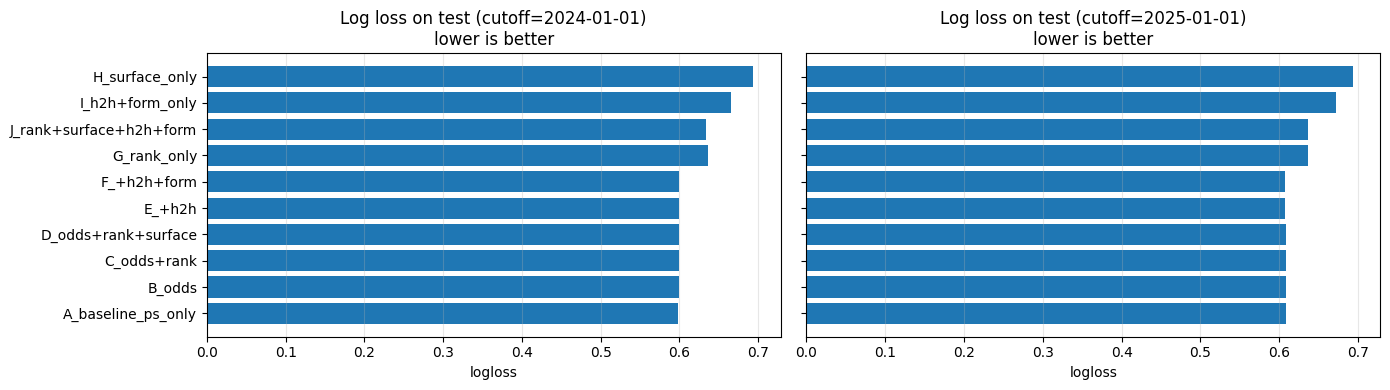

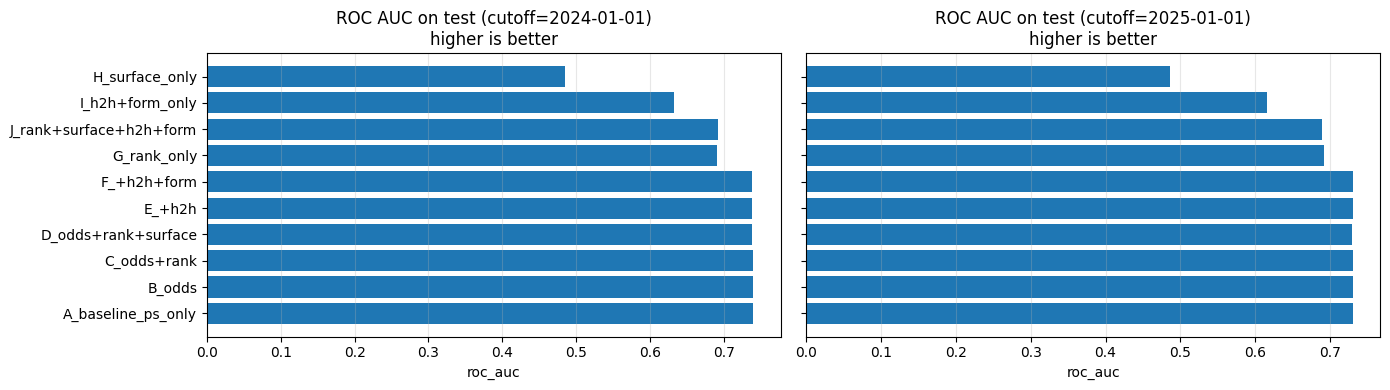

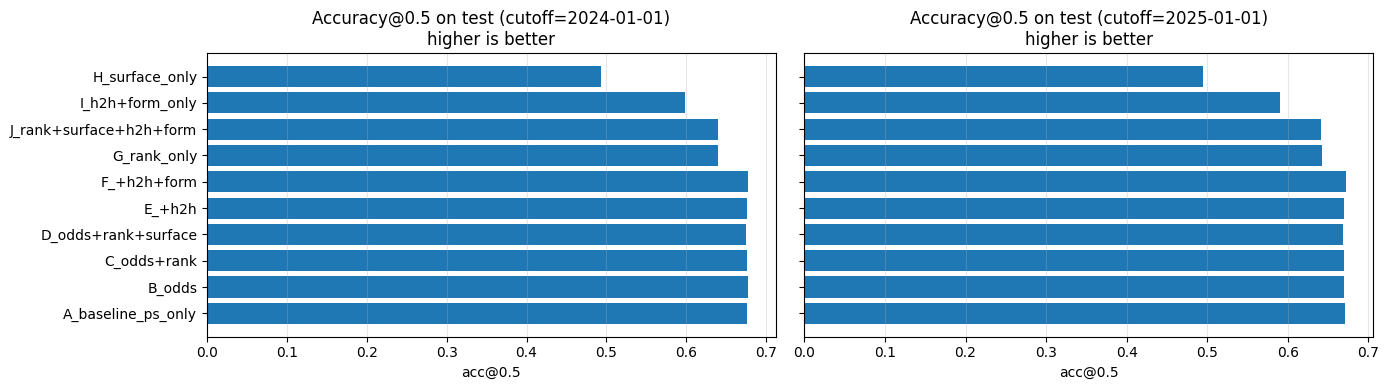

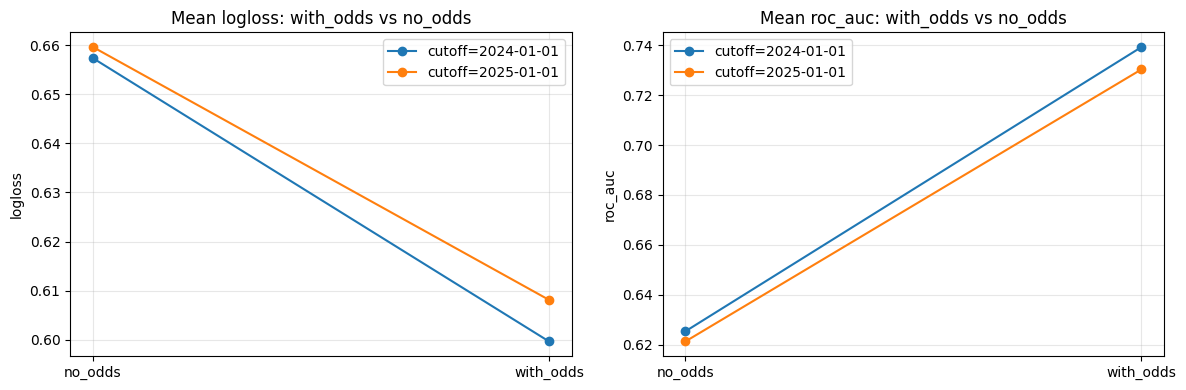

In [15]:
# Plots for metrics across models and cutoffs
import os
import matplotlib.pyplot as plt

os.makedirs('figures', exist_ok=True)

# Expect `all_res` from cell 14
plot_df = all_res.copy()

# order models in a meaningful way
model_order = [
    'A_baseline_ps_only',
    'B_odds',
    'C_odds+rank',
    'D_odds+rank+surface',
    'E_+h2h',
    'F_+h2h+form',
    'G_rank_only',
    'J_rank+surface+h2h+form',
    'I_h2h+form_only',
    'H_surface_only',
]
plot_df['model'] = pd.Categorical(plot_df['model'], categories=model_order, ordered=True)
plot_df = plot_df.sort_values(['cutoff', 'model'])

# Helper to plot metric and save figure

def plot_metric(metric: str, title: str, better: str, out_path: str):
    fig, axes = plt.subplots(1, plot_df['cutoff'].nunique(), figsize=(14, 4), sharey=True)
    if plot_df['cutoff'].nunique() == 1:
        axes = [axes]

    for ax, cutoff in zip(axes, sorted(plot_df['cutoff'].unique())):
        sub = plot_df[plot_df['cutoff'] == cutoff].dropna(subset=[metric])
        ax.barh(sub['model'].astype(str), sub[metric])
        ax.set_title(f'{title} (cutoff={cutoff})\n{better} is better')
        ax.set_xlabel(metric)
        ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    fig.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()


plot_metric('logloss', 'Log loss on test', 'lower', 'figures/metrics_logloss_by_model.png')
plot_metric('roc_auc', 'ROC AUC on test', 'higher', 'figures/metrics_auc_by_model.png')
plot_metric('acc@0.5', 'Accuracy@0.5 on test', 'higher', 'figures/metrics_acc_by_model.png')

# Compact view: odds vs no-odds groups
plot_df['group'] = np.where(
    plot_df['model'].astype(str).str.contains('odds')
    | plot_df['model'].astype(str).str.startswith(('A_', 'B_', 'C_', 'D_', 'E_', 'F_')),
    'with_odds',
    'no_odds'
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ['logloss', 'roc_auc']):
    for cutoff in sorted(plot_df['cutoff'].unique()):
        sub = plot_df[plot_df['cutoff'] == cutoff]
        agg = sub.groupby('group')[metric].mean()
        ax.plot(
            ['no_odds', 'with_odds'],
            [agg.get('no_odds', np.nan), agg.get('with_odds', np.nan)],
            marker='o',
            label=f'cutoff={cutoff}',
        )
    ax.set_title(f'Mean {metric}: with_odds vs no_odds')
    ax.set_ylabel(metric)
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
fig.savefig('figures/with_odds_vs_no_odds.png', dpi=200, bbox_inches='tight')
plt.show()